In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load dataset
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings', 'Employment', 'InstallmentRate',
    'PersonalStatusSex', 'Debtors', 'ResidenceSince', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing',
    'ExistingCredits', 'Job', 'NumDependents', 'OwnPhone', 'ForeignWorker', 'Default'
]
df = pd.read_csv('german.data', delim_whitespace=True, header=None, names=columns)
df.head()

<ipython-input-4-96b46874fb62>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('german.data', delim_whitespace=True, header=None, names=columns)


,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,NumDependents,OwnPhone,ForeignWorker,Default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [7]:
categorical_cols = [
    'Status', 'CreditHistory', 'Purpose', 'Savings', 'Employment',
    'PersonalStatusSex', 'Debtors', 'Property', 'OtherInstallmentPlans',
    'Housing', 'Job', 'OwnPhone', 'ForeignWorker'
]

# one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# encode the default flag explicitly
df_encoded['Default'] = df['Default'].map({1: 0, 2: 1})

# define features and target
X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# SMOTE to improve sampling
!pip install imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [16]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5076 - auc: 0.5268 - loss: 0.7957 - val_accuracy: 0.5134 - val_auc: 0.6032 - val_loss: 0.6800
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5741 - auc: 0.6177 - loss: 0.7020 - val_accuracy: 0.6205 - val_auc: 0.7206 - val_loss: 0.6416
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6300 - auc: 0.6641 - loss: 0.6728 - val_accuracy: 0.7143 - val_auc: 0.7844 - val_loss: 0.6073
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6484 - auc: 0.7099 - loss: 0.6238 - val_accuracy: 0.7545 - val_auc: 0.8144 - val_loss: 0.5773
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6718 - auc: 0.7263 - loss: 0.6116 - val_accuracy: 0.7679 - val_auc: 0.8356 - val_loss: 0.5488
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7286 - auc: 0.7912 - loss: 0.5535 - val_accuracy: 0.7634 - val_auc: 0.8491 - val_loss: 0.5220
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       149
           1       0.74      0.86      0.80       131

    accuracy                           0.80       280
   macro avg       0.80      0.80      0.80       280
weighted avg       0.81      0.80      0.80       280



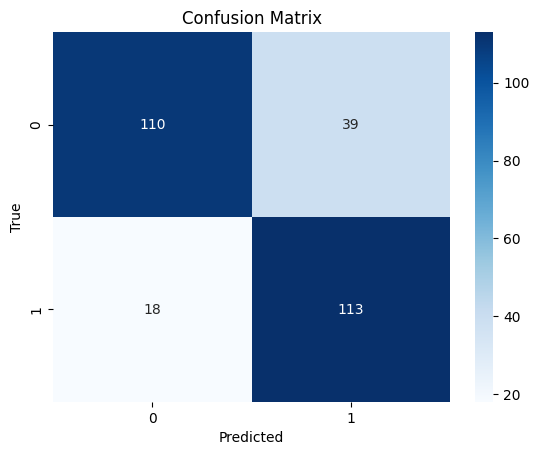

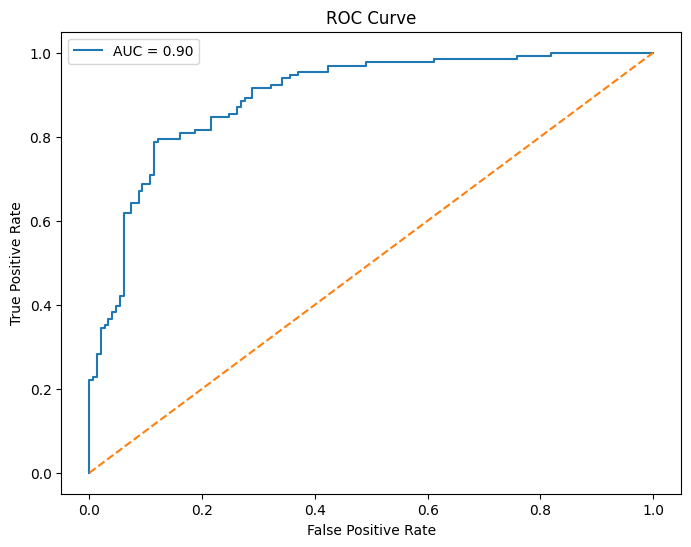

In [18]:
# evaluate on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC-AUC curve
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#Cross-fold validation

In [13]:
from sklearn.model_selection import StratifiedKFold

In [14]:
def create_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

In [15]:
n_splits = 5
epochs = 50
batch_size = 32

# stratified k-fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_scores = []
auc_scores = []
fold_no = 1

for train_index, test_index in skf.split(X_scaled, y):
    print(f'\nTraining on fold {fold_no}...')

    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]


    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)


    model = create_model(X_train_res.shape[1])
    model.fit(X_train_res, y_train_res, epochs=epochs, batch_size=batch_size, verbose=0)


    scores = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    accuracy = scores[1]
    auc = scores[2]

    accuracy_scores.append(accuracy)
    auc_scores.append(auc)

    print(f'Fold {fold_no} - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}')

    fold_no += 1

# summarize results
print("\nCross-validation results:")
print(f"Average accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


Training on fold 1...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 - Accuracy: 0.6750, AUC: 0.7265

Training on fold 2...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 - Accuracy: 0.7250, AUC: 0.7291

Training on fold 3...


...

Fold 3 - Accuracy: 0.7300, AUC: 0.7749

Training on fold 4...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 - Accuracy: 0.7150, AUC: 0.7750

Training on fold 5...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 - Accuracy: 0.7200, AUC: 0.7901

Cross-validation results:
Average accuracy: 0.7130 ± 0.0196
Average AUC: 0.7591 ± 0.0262


In [20]:
model.save("tf-credit-v2.keras")